# NBXX: Revised population synthesis pipeline

This notebook will hold the final version of the population synthesis pipeline, for both the linear interpolation and surrogate model versions. Consistency checks, quality tests and comparisons can be found here, as well as instructions for how to use the tool. The main code should be reserved to one of the modules in `../src`.

In [1]:
nb_id = "xx"

## Setup

In [2]:
from dataclasses import dataclass
from pathlib import Path
import pickle as pkl
from functools import partial
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

from astropy.cosmology import WMAP9 as cosmo


import sys
sys.path.append('..')
from src.util import DATA_DIR, savefig_base
from src.constants import Z_SUN
from src.popsynth import SamplingConfig
FIGURE_FOLDER = Path(f'../figures/nb{nb_id}')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FOLDER = DATA_DIR / 'nb_output' / f'nb{nb_id}'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

IP_POP_DIR = DATA_DIR / 'output' / 'ip_pop'
IP_POP_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('./plotstyle.mplstyle')
pd.set_option('display.max_columns', None)

In [3]:
def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

In [4]:
from src.popsynth import get_complete_core_props_df

In [5]:
fiducial00_core_props_df = get_complete_core_props_df(DATA_DIR/'00_fiducial_core_props_df_v7.h5')

## Population synthesis

In [6]:
from src.popsynth import get_metallicity_distribution_ip

In [7]:
from src.popsynth import PopSynth

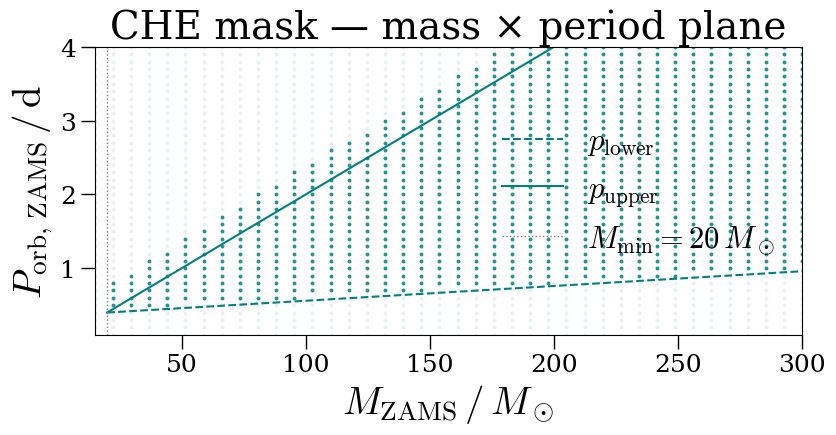

<Axes: title={'center': 'CHE mask — mass × period plane'}, xlabel='$M_\\mathrm{ZAMS}\\,/\\,M_\\odot$', ylabel='$P_\\mathrm{orb,\\,ZAMS}\\,/\\,\\mathrm{d}$'>

In [8]:
from src.popsynth import LinearCHEWindowMask, CHE_M_MIN, CHE_P_MIN, CHE_LOWER_SLOPE, CHE_UPPER_SLOPE

def plot_che_mask(
    che_m_min=CHE_M_MIN,
    che_p_min=CHE_P_MIN,
    che_lower_slope=CHE_LOWER_SLOPE,
    che_upper_slope=CHE_UPPER_SLOPE,
    m_range=(15, 300),
    p_range=(0.1, 4.0),
    resolution=40,
    ax=None,
):
    """Scatter plot of a regular grid on the mass × period plane.

    Points inside the CHE window are fully opaque; points outside are translucent.
    """
    m_grid = np.linspace(*m_range, resolution)
    p_grid = np.linspace(*p_range, resolution)
    M, P = np.meshgrid(m_grid, p_grid)
    m_flat, p_flat = M.ravel(), P.ravel()

    getter = LinearCHEWindowMask(che_m_min, che_p_min, che_lower_slope, che_upper_slope)
    inside = getter(m_flat, p_flat)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))
    else:
        fig = ax.get_figure()

    ax.scatter(m_flat[~inside], p_flat[~inside], s=8, color='steelblue', alpha=0.12, linewidths=0)
    ax.scatter(m_flat[inside],  p_flat[inside],  s=8, color='teal',      alpha=0.85, linewidths=0)

    # Boundary lines
    m_line = np.linspace(che_m_min, m_range[1], 500)
    ax.plot(m_line, che_lower_slope * (m_line - che_m_min) + che_p_min,
            color='teal', lw=1.5, ls='--', label='$p_\\mathrm{lower}$')
    ax.plot(m_line, che_upper_slope * (m_line - che_m_min) + che_p_min,
            color='teal', lw=1.5, ls='-',  label='$p_\\mathrm{upper}$')
    ax.axvline(che_m_min, color='gray', lw=1.0, ls=':',
               label=f'$M_\\mathrm{{min}}={che_m_min:.0f}\\,M_\\odot$')

    ax.set_xlim(*m_range)
    ax.set_ylim(*p_range)
    ax.set_xlabel('$M_\\mathrm{ZAMS}\\,/\\,M_\\odot$')
    ax.set_ylabel('$P_\\mathrm{orb,\\,ZAMS}\\,/\\,\\mathrm{d}$')
    ax.set_title('CHE mask — mass × period plane')
    ax.legend(frameon=False)

    if standalone:
        fig.tight_layout()
        plt.show()
    return ax


plot_che_mask()

In [9]:
def get_standard_sample(
        core_props_df, 
        title_base='',
        write_to_disk=False, 
        n_processes=4, 
        verbose=True, 
        res=int(1e7),
        model='interpolator', 
        metallicity='loguniform',
        cpu_affinity_count=None):
    vars=[
        'm_f',
        'p_orb_f',
        'x_f',
        'x_min_f',
        'm_tams',
        'x_tams',
        'log_t_d',
    ]
    vars_index_dict = {var: i for i, var in enumerate(vars)}
    
    if cpu_affinity_count is not None:
        if cpu_affinity_count > os.cpu_count():
            print(f"Requested cpu_affinity_count={cpu_affinity_count} exceeds available CPUs ({os.cpu_count()}). Using all available CPUs.")
            cpu_affinity_count = os.cpu_count()
    
    title = f'{model}_{title_base}'

    ip_cut_non_he_depl=True

    try:
        original_affinity = os.sched_getaffinity(0)
        os.sched_setaffinity(0, set(range(cpu_affinity_count)))
        print(f"Set CPU affinity to use {cpu_affinity_count} CPUs: {set(range(cpu_affinity_count))}")
    except AttributeError:
        original_affinity = None
        print("os.sched_setaffinity not available on this platform. Continuing without setting CPU affinity.")

    try:
        popsynth = PopSynth(
            core_props_df=core_props_df, 
            ip_cut_non_he_depl=ip_cut_non_he_depl, 
            title=title, 
            n_processes=n_processes, 
            verbose=verbose,
            )
        popsynth.fit(
            vars=vars,
            model=model
        )

        draw_pop_kwargs = dict(
            vars=vars,
            apply_che_mask=True,
            metallicity=metallicity,
            redshift=1.,
            res=res,
            min_m=20,
            max_m=300,
            min_p=0.1,
            max_p=4,
            min_zdivzsun=0.0005,
            max_zdivzsun=1.0,
            write_to_disk=write_to_disk,
        )

        sample, msample = popsynth.draw_pop(**draw_pop_kwargs)

    finally:
        if original_affinity is not None:
            print(f"Restoring original CPU affinity: {original_affinity}")
            os.sched_setaffinity(0, original_affinity)

    return sample, msample, vars_index_dict

In [10]:

from src.popsynth import find_metallicity_distribution


_X_COL_ALPHAS = [1.0, 0.2]

# Shared metallicity binning — covers the full loguniform range (0.0005–1.0 Z/Zsun)
_Z_INTERVALS = np.logspace(np.log10(0.0005), np.log10(0.4), 7)   # 6 bins: 0.001–0.01, …, 0.1–0.4 in Z/Zsun
_Z_MIDPOINTS = np.sqrt(_Z_INTERVALS[:-1] * _Z_INTERVALS[1:])
_Z_LOG_MIDPOINTS = np.log10(_Z_MIDPOINTS)
_Z_NORM = plt.Normalize(_Z_LOG_MIDPOINTS.min(), _Z_LOG_MIDPOINTS.max())


def _z_color(i):
    return plt.cm.viridis(_Z_NORM(_Z_LOG_MIDPOINTS[i]))


def _z_bin_mask(arr_col0, i):
    lo, hi = _Z_INTERVALS[i], _Z_INTERVALS[i + 1]
    if i == len(_Z_INTERVALS) - 2:
        return (arr_col0 >= lo) & (arr_col0 <= hi)
    return (arr_col0 >= lo) & (arr_col0 < hi)


def _get_van_son_bin_weights(redshift):
    """Integrate van Son 2022 dp/dlogZ over each _Z_INTERVALS bin at the given redshift."""
    _min_logz, _max_logz, _step_logz = -12.0, 0.0, 0.01
    z_arr = np.array([float(redshift)])
    dp_dlogz, metallicities_abs, _ = find_metallicity_distribution(
        z_arr,
        min_logz_compas=np.log(0.0005 * Z_SUN),
        max_logz_compas=np.log(1.0    * Z_SUN),
        mu_0=0.025, mu_z=-0.049, sigma_0=1.122, sigma_z=0.049, alpha=-1.778,
        min_logz=_min_logz, max_logz=_max_logz, step_logz=_step_logz,
    )
    dp1d = dp_dlogz[0]
    log_mets = np.log(metallicities_abs)
    weights = np.zeros(len(_Z_INTERVALS) - 1)
    for i in range(len(_Z_INTERVALS) - 1):
        lo = np.log(_Z_INTERVALS[i]     * Z_SUN)
        hi = np.log(_Z_INTERVALS[i + 1] * Z_SUN)
        mask = (log_mets >= lo) & (log_mets < hi)
        weights[i] = dp1d[mask].sum() * _step_logz
    return weights


def _sample_bin_weights(sample_col0, bin_weights):
    """Map per-sample metallicity to its bin weight."""
    w = np.ones(len(sample_col0))
    for j in range(len(_Z_INTERVALS) - 1):
        mask = _z_bin_mask(sample_col0, j)
        w[mask] = bin_weights[j]
    return w


def _apply_ylim(ax, log_y):
    """Set y-axis limits with appropriate padding and scale."""
    if log_y:
        ax.set_yscale('log')
        y_upper = ax.get_ylim()[1] * 3.0
        ax.set_ylim(0.5, y_upper)
    else:
        y_upper = ax.get_ylim()[1] * 1.15
        ax.set_ylim(0, y_upper)
    return y_upper


_MERGER_COLOR    = 'C0'
_NONMERGER_COLOR = 'C1'


def plot_mf_hist(samples, ax, legend, log_y=False, bin_weights=None):
    """Stacked histogram of counts split by t_d <= T_H (mergers) and t_d > T_H."""
    bins = np.linspace(5, 100, 50)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths  = np.diff(bins)
    log_t_H = np.log10(PopSynth.T_H)

    for i_col, sample in enumerate(samples):
        alpha = _X_COL_ALPHAS[i_col] if i_col < len(_X_COL_ALPHAS) else _X_COL_ALPHAS[-1]

        merger_mask    = sample[:, -1] <= log_t_H
        nonmerger_mask = ~merger_mask

        _w = _sample_bin_weights(sample[:, 0], bin_weights) if bin_weights is not None else None
        counts_m,  _ = np.histogram(sample[merger_mask,    3], bins=bins,
                                    weights=_w[merger_mask]    if _w is not None else None)
        counts_nm, _ = np.histogram(sample[nonmerger_mask, 3], bins=bins,
                                    weights=_w[nonmerger_mask] if _w is not None else None)

        ax.bar(bin_centers, counts_m,  width=bin_widths, align='center',
               color=_MERGER_COLOR,    edgecolor='black', linewidth=0.5,
               alpha=alpha, label='$t_\\mathrm{d}\\leq t_\\mathrm{H}$' if i_col == 0 else None)
        ax.bar(bin_centers, counts_nm, width=bin_widths, align='center',
               color=_NONMERGER_COLOR, edgecolor='black', linewidth=0.5,
               alpha=alpha, bottom=counts_m,
               label='$t_\\mathrm{d}>t_\\mathrm{H}$' if i_col == 0 else None)

    y_upper = _apply_ylim(ax, log_y)
    ax.vlines(35, ax.get_ylim()[0], y_upper, color='k', lw=0.8)
    ax.text(35, y_upper * (0.5 if log_y else 0.88), '$35\\,\\mathrm{M}_\\odot$',
            ha='left', va='center', fontsize=10)
    ax.set_xlabel('$M/M_\\odot$')
    ax.set_ylabel('$N$')
    if legend:
        ax.legend(frameon=False)


def plot_mf_stacked(samples, ax, legend, x_labels=None, log_y=False, bin_weights=None):
    bins = np.linspace(5, 100, 50)
    bin_widths = np.diff(bins)
    colors = [_z_color(j) for j in range(len(_Z_INTERVALS) - 1)]

    for i_col, sample in enumerate(samples):
        alpha = _X_COL_ALPHAS[i_col] if i_col < len(_X_COL_ALPHAS) else _X_COL_ALPHAS[-1]
        bottom = np.zeros(len(bins) - 1)
        for j in range(len(_Z_INTERVALS) - 1):
            mask = _z_bin_mask(sample[:, 0], j)
            if mask.sum() == 0:
                continue
            _w = _sample_bin_weights(sample[mask, 0], bin_weights) if bin_weights is not None else None
            counts, _ = np.histogram(sample[mask, 3], bins=bins, weights=_w)
            ax.bar(
                (bins[:-1] + bins[1:]) / 2,
                counts,
                width=bin_widths,
                bottom=bottom,
                color=colors[j],
                edgecolor='black',
                linewidth=0.5,
                align='center',
                alpha=alpha,
            )
            bottom += counts

    y_upper = _apply_ylim(ax, log_y)
    ax.vlines(35, ax.get_ylim()[0], y_upper, color='k', lw=0.8)
    ax.text(35, y_upper * (0.5 if log_y else 0.88), '$35\\,\\mathrm{M}_\\odot$',
            ha='left', va='center', fontsize=10)
    ax.set_xlabel('$M/M_\\odot$')
    ax.set_ylabel('$N$')

    if legend and x_labels is not None:
        alpha_handles = [
            Patch(facecolor='gray', edgecolor='black', linewidth=0.5,
                  alpha=_X_COL_ALPHAS[i] if i < len(_X_COL_ALPHAS) else _X_COL_ALPHAS[-1],
                  label=lbl)
            for i, lbl in enumerate(x_labels)
        ]
        ax.legend(handles=alpha_handles, frameon=False, loc='upper right', bbox_to_anchor=(1, 1))
        


def plot_mf_kde(sample, msample, ax, legend):
    y_lower = 1e-3
    pad_factor = 2.0

    for i in range(len(_Z_INTERVALS) - 1):
        mask = _z_bin_mask(sample[:, 0], i)
        sns.kdeplot(sample[mask, 3], ax=ax, color=_z_color(i), linestyle='--')

    for i in range(len(_Z_INTERVALS) - 1):
        mask = _z_bin_mask(msample[:, 0], i) & ~np.isnan(msample[:, 3])
        sns.kdeplot(msample[mask, 3], ax=ax, color=_z_color(i), linestyle='-')

    ax.set_yscale('log')
    ax.set_xlim(1, 110)
    y_upper = ax.get_ylim()[1] * pad_factor
    ax.vlines(35, 0, y_upper, color='k', lw=0.8)
    ax.text(35, y_upper * 0.5, '$35\\,\\mathrm{M}_\\odot$', ha='left', va='center', fontsize=14)
    ax.set_ylim(y_lower, y_upper)
    ax.set_xlabel('$M_\\mathrm{f} \\, / \\, \\mathrm{M}_\\odot$')
    ax.set_ylabel('$\\mathrm{d}N/\\mathrm{d}M_f\\,(\\mathrm{M}_\\odot^{-1})$')

    if legend:
        metallicity_handles = [
            Patch(color=_z_color(i),
                  label=f'${_Z_LOG_MIDPOINTS[i]-0.5*np.log10(_Z_INTERVALS[i+1]/_Z_INTERVALS[i]):.1f}'
                        f'<\\log Z/Z_\\odot\\leq'
                        f'{np.log10(_Z_INTERVALS[i+1]):.1f}$')
            for i in range(len(_Z_MIDPOINTS))
        ]
        line_handles = [
            Line2D([0], [0], color='k', linestyle='-',  label='$t_d < t_H$'),
            Line2D([0], [0], color='k', linestyle='--', label='Full sample'),
        ]
        ax.legend(handles=metallicity_handles + line_handles, frameon=False,
                  bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)


def plot_logtd_vs_mass(sample, ax, xlabel, ls='-', legend=False, log_t_max=None, z_intervals=_Z_INTERVALS):
    """Smoothed 2D KDE contours of log_t_d vs mass for mergers, one per metallicity bin."""
    valid = ~np.isnan(sample[:, -1]) & ~np.isnan(sample[:, -2]) & (sample[:, -2] > 0)
    arr = sample[valid]
    if len(arr) == 0:
        return

    handles = []
    for i in range(len(z_intervals) - 1):
        mask = _z_bin_mask(arr[:, 0], i)
        #if mask.sum() < 50:
        #    continue
        color = _z_color(i)
        sns.kdeplot(x=arr[mask, -2], y=arr[mask, -1], ax=ax,
                    color=color, linestyles=ls, levels=3, alpha=0.85, linewidths=2.0)
        handles.append(Line2D([0], [0], color=color,
            label=f"${np.log10(z_intervals[i]):.1f}<\log Z/Z_\odot\leq{np.log10(z_intervals[i+1]):.1f}$"))

    ax.set_xlabel(xlabel + "$\,/\,M_\odot$")
    ax.set_ylabel("$\log\,t_\mathrm{d}\,/\,\mathrm{yr}$")

    if log_t_max is None:
        log_t_max = np.log10(PopSynth.T_H)

    ax.hlines(log_t_max, *ax.get_xlim(), color='k', lw=0.8, ls='--')

    if legend and handles:
        ax.legend(handles=handles, frameon=False,
                  bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)


def plot_results_panel(sample, msample, figsize=(14, 10), title=None):
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35)

    ax_hist    = fig.add_subplot(gs[1, 0])
    ax_stacked = fig.add_subplot(gs[1, 1])
    ax_kde     = fig.add_subplot(gs[0, :])

    plot_mf_kde(sample, msample, ax_kde, legend=True)
    plot_mf_hist([sample], ax_hist, legend=True)
    plot_mf_stacked([sample], ax_stacked, legend=False)

    if title:
        fig.suptitle(title, fontsize=14)
    return fig


def plot_results_panel_df(sample_df, msample_df, x_col='m_f', figsize=(22, 15), title=None, save_figure=False, log_y=False, z_weight_redshift=None, mergers_only=False):
    X_LABELS = {
        'm_zams':    '$M_\\mathrm{ZAMS}$',
        'm_f':       '$M_\\mathrm{f}$',
        'm_tams':    '$M_\\mathrm{TAMS}$',
        'm_post_pi': '$M_\\mathrm{post-PI}$',
    }

    x_cols   = [x_col] if isinstance(x_col, str) else list(x_col)
    x_labels = [X_LABELS.get(col, col) for col in x_cols]

    _bin_weights = _get_van_son_bin_weights(z_weight_redshift) if z_weight_redshift is not None else None

    def make_sample_arrays(df, col):
        arr = np.column_stack([
            df.z_div_zsun.values,
            np.zeros(len(df)),   # col 1 placeholder
            np.zeros(len(df)),   # col 2 placeholder
            df[col].values,
            df.log_t_d.values,
        ])
        return arr[arr[:, -2] > 0]

    sample_mf   = make_sample_arrays(sample_df,  'm_f')
    msample_mf  = make_sample_arrays(msample_df, 'm_f')
    sample_mpi  = make_sample_arrays(sample_df,  'm_post_pi')
    msample_mpi = make_sample_arrays(msample_df, 'm_post_pi')

    samples  = [make_sample_arrays(sample_df,  col) for col in x_cols]

    _log_t_H = np.log10(PopSynth.T_H)
    if z_weight_redshift is None:
        _log_t_max = _log_t_H
    else:
        _log_t_max = cosmo.lookback_time(z_weight_redshift).value * 1e9  # Gyr -> yr
        _log_t_max = np.log10(_log_t_max)

    if mergers_only:    
        samples = [s[s[:, -1] <= _log_t_max] for s in samples]

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

    # Row 0 — log_td vs mass contours
    ax_td_mf   = fig.add_subplot(gs[0, 0])
    ax_td_mpi  = fig.add_subplot(gs[0, 1])
    # Row 1 — KDE
    ax_kde_mf  = fig.add_subplot(gs[1, 0])
    ax_kde_mpi = fig.add_subplot(gs[1, 1])
    # Row 2 — hist / stacked
    ax_hist    = fig.add_subplot(gs[2, 0])
    ax_stacked = fig.add_subplot(gs[2, 1])

    plot_logtd_vs_mass(sample_mf,  ax_td_mf,  xlabel=X_LABELS['m_f'],       legend=False, ls='--', log_t_max=_log_t_max)
    plot_logtd_vs_mass(msample_mf, ax_td_mf,  xlabel=X_LABELS['m_f'],       legend=False, ls='-', log_t_max=_log_t_max)
    plot_logtd_vs_mass(sample_mpi, ax_td_mpi, xlabel=X_LABELS['m_post_pi'], legend=False, ls='--', log_t_max=_log_t_max)
    plot_logtd_vs_mass(msample_mpi, ax_td_mpi, xlabel=X_LABELS['m_post_pi'], legend=False, ls='-', log_t_max=_log_t_max)

    plot_mf_kde(sample_mf,  msample_mf,  ax_kde_mf,  legend=False)
    ax_kde_mf.set_xlabel(X_LABELS['m_f'] + '$\\,/\\,M_\\odot$')
    plot_mf_kde(sample_mpi, msample_mpi, ax_kde_mpi, legend=True)
    ax_kde_mpi.set_xlabel(X_LABELS['m_post_pi'] + '$\\,/\\,M_\\odot$')

    plot_mf_hist(samples, ax_hist, legend=True, log_y=log_y, bin_weights=_bin_weights)
    plot_mf_stacked(samples, ax_stacked, legend=True, log_y=log_y,
                    x_labels=x_labels if len(x_cols) > 1 else None,
                    bin_weights=_bin_weights)

    if len(x_cols) == 1:
        ax_hist.set_xlabel(x_labels[0] + '$\\,/\\,M_\\odot$')
        ax_stacked.set_xlabel(x_labels[0] + '$\\,/\\,M_\\odot$')

    _effective_title = title or ''
    if mergers_only:
        _effective_title = f'{_effective_title} | mergers only' if _effective_title else 'mergers only'
    if z_weight_redshift is not None:
        _ztag = f'van Son Z-weight z={z_weight_redshift:.2f}'
        _effective_title = f'{_effective_title} | {_ztag}' if _effective_title else _ztag
    if _effective_title:
        fig.suptitle(_effective_title, fontsize=14)
    if save_figure and title:
        savefig(fig, f'panel_{title}')

    return fig

In [11]:
PPISN_CONFIG_PATH = DATA_DIR / 'farag_high_res_ppisn_config.pkl'
with open(PPISN_CONFIG_PATH, 'rb') as f:
    farag_high_res_config = pkl.load(f)


@dataclass
class FaragLowResPPISNConfig:
    """Farag+22 PPISN configuration for the Farmer+20 res and 52-tp DeBoer c12ag rates."""
    # Renzo+2020 cubic polynomial coefficients
    c3_log_slope: float = 0.0006
    c3_intercept: float = 0.0054
    c2: float = -0.0013
    m_co_ref: float = 34.8
    # He-core mass thresholds (default)
    m_he_ppisn: float = 55
    m_he_pisn: float = 70
    m_he_pd: float = 135
    # CO-core mass thresholds (fixed to same as he, data unavailable)
    m_co_ppisn: float = 55
    m_co_pisn: float = 70
    m_co_pd: float = 135
    # Which core mass to use for the fate thresholds: 'he' or 'co'
    threshold_core: str = 'he'

    @property
    def ppisn_th(self):
        return self.m_co_ppisn if self.threshold_core == 'co' else self.m_he_ppisn

    @property
    def pisn_th(self):
        return self.m_co_pisn if self.threshold_core == 'co' else self.m_he_pisn

    @property
    def pd_th(self):
        return self.m_co_pd if self.threshold_core == 'co' else self.m_he_pd


def renzo_ppisn(m_tot, m_co, z, config=farag_high_res_config, metallicity_multiplier=1.):
    z *= metallicity_multiplier
    delta_ppi = (
        (config.c3_log_slope * np.log10(z) + config.c3_intercept)
        * (m_co - config.m_co_ref) ** 3
        - config.c2 * (m_co - config.m_co_ref) ** 2
    )
    delta_ppi = np.clip(delta_ppi, 0.0, None)
    return np.clip(m_tot - delta_ppi, 0.0, None)


def get_post_pi_mass(sample_df, config=farag_high_res_config, mass_th_col='m_cocore_tahems', metallicity_multiplier=1.): 
    m_post_pi = np.zeros(sample_df.shape[0])
    fate_type = np.asarray(['missing'] * sample_df.shape[0], dtype=str)

    stable_mask = sample_df[mass_th_col] < config.ppisn_th
    ppsin_mask = (sample_df[mass_th_col] >= config.ppisn_th) & (sample_df[mass_th_col] < config.pisn_th)
    pisn_mask = (sample_df[mass_th_col] >= config.pisn_th) & (sample_df[mass_th_col] < config.pd_th)
    photodisintegration_mask = sample_df[mass_th_col] >= config.pd_th

    if mass_th_col.startswith('m_cocore') or mass_th_col.startswith('m_hecore'):
        m_co = sample_df[mass_th_col]
    else:
        m_co = sample_df.m_cocore_f if 'm_cocore_f' in sample_df.columns else sample_df.m_f



    fate_type[stable_mask] = 'ccsn'
    m_post_pi[stable_mask] = sample_df.m_f[stable_mask].to_numpy()

    fate_type[ppsin_mask] = 'ppisn'
    m_post_pi[ppsin_mask] = renzo_ppisn(sample_df.m_f[ppsin_mask].to_numpy(), m_co[ppsin_mask].to_numpy(), sample_df.z_div_zsun[ppsin_mask].to_numpy()*Z_SUN, config, metallicity_multiplier=metallicity_multiplier)

    fate_type[pisn_mask] = 'pisn'
    m_post_pi[pisn_mask] = 0.0

    fate_type[photodisintegration_mask] = 'pd'
    m_post_pi[photodisintegration_mask] = sample_df.m_f[photodisintegration_mask].to_numpy()

    sample_df['m_post_pi'] = m_post_pi
    sample_df['fate_type'] = fate_type

    print(f'len missing: {(fate_type == "missing").sum()}')
    print(f'len stable: {stable_mask.sum()}')
    print(f'len ppisn: {ppsin_mask.sum()}')
    print(f'len pisn: {pisn_mask.sum()}')
    print(f'len pd: {photodisintegration_mask.sum()}')
    print(f'len total: {stable_mask.sum() + ppsin_mask.sum() + pisn_mask.sum() + photodisintegration_mask.sum()}')
    return sample_df

In [12]:
DEFAULT_SAMPLING_CONFIG = SamplingConfig(
    min_z_div_zsun=5e-4,
    max_z_div_zsun=1e0,
    m_min=10.,
    m_max=300.,
    q_min=0.7,
    q_max=1.0,
    p_min=1e-1,
    p_max=1e4,
)

def get_sample_df(
    core_props_df,
    dense_core_props_df,
    title_base='',
    save_to_disk=False,
    force_regen_sample=False,
    n_processes=4,
    verbose=True,
    res=int(1e7),
    model='interpolator',
    metallicity='loguniform',
    cpu_affinity_count=None,
    ppisn_config=farag_high_res_config,
    fallback_to_interpolator_for_logtd=False,
    correction_factors=("mi",),
    extrapolate_z_islands=False,
    ppi_mass_th_col='m_cocore_tahems',
    sampling_config=DEFAULT_SAMPLING_CONFIG,
    apply_che_mask=False,
    redshift=1.0,
    delta_ppi_metallicity_multiplier=1.0,
    map_core_props_df=None,
    interpolate_diagonals=False,
):
    vars = [
        'm_f',
        'p_orb_f',
        'x_f',
        'x_min_f',
        'm_tams',
        'x_tams',
        'log_t_d',
        ppi_mass_th_col
    ]
    # code below is superceded by ppi_mass_th_col
    # v6 grids expose an explicit final CO-core mass; interpolate it so
    # get_post_pi_mass can use the real M_CO in the PPISN prescription.
    #if 'm_cocore_f' in core_props_df.columns:
    #    vars.append('m_cocore_f')
    vars_index_dict = {var: i for i, var in enumerate(vars)}

    if cpu_affinity_count is not None and cpu_affinity_count > os.cpu_count():
        print(
            f"Requested cpu_affinity_count={cpu_affinity_count} exceeds available CPUs ({os.cpu_count()}). Using all available CPUs."
        )
        cpu_affinity_count = os.cpu_count()

    # Include correction factors in title so different configurations get distinct filenames.
    if model == 'corrected':
        factors_str = '_'.join(sorted(correction_factors)) if correction_factors else 'none'
        model_tag = f'corrected_{factors_str}'
    else:
        model_tag = model

    title = f'{model_tag}_{title_base}'
    tag = f'ip_pop_minz5e-4_maxz1e0_{metallicity}_{model}_res{res:.0e}_zext{extrapolate_z_islands}_{title}'
    sample_df_path = IP_POP_DIR / f'{tag}_df.h5'
    sampling_config_path = IP_POP_DIR / f'{tag}_sampling_config.pkl'

    # Cache hit: load existing dataframe unless forced regeneration is requested.
    if sample_df_path.exists() and not force_regen_sample:
        print(f'Loading existing sample dataframe: {sample_df_path}')
        sample_df = pd.read_hdf(sample_df_path, key='df')
    else:
        print(f'No sample at {sample_df_path}, or force_regen_sample=True. Generating new sample...')
        ip_cut_non_he_depl = True

        try:
            original_affinity = os.sched_getaffinity(0)
            if cpu_affinity_count is not None:
                os.sched_setaffinity(0, set(range(cpu_affinity_count)))
                print(
                    f"Set CPU affinity to use {cpu_affinity_count} CPUs: {set(range(cpu_affinity_count))}"
                )
        except AttributeError:
            original_affinity = None
            print(
                'os.sched_setaffinity not available on this platform. Continuing without setting CPU affinity.'
            )

        try:
            popsynth = PopSynth(
                core_props_df=core_props_df,
                map_core_props_df=map_core_props_df,
                dense_core_props_df=dense_core_props_df,
                ip_cut_non_he_depl=ip_cut_non_he_depl,
                title=title,
                n_processes=n_processes,
                verbose=verbose,
                fallback_to_interpolator_for_logtd=fallback_to_interpolator_for_logtd,
                correction_factors=correction_factors,
                extrapolate_z_islands=extrapolate_z_islands,
                interpolate_diagonals=interpolate_diagonals,
            )
            popsynth.fit(vars=vars, model=model)

            sample, _ = popsynth.draw_pop(
                vars=vars,
                metallicity=metallicity, 
                res=res, 
                write_to_disk=save_to_disk, 
                apply_che_mask=apply_che_mask, 
                redshift=redshift,
                sampling_config=sampling_config,
                )
        finally:
            if original_affinity is not None:
                print(f'Restoring original CPU affinity: {original_affinity}')
                os.sched_setaffinity(0, original_affinity)

        cols = ['z_div_zsun', 'm_zams', 'p_spin_zams'] + list(vars_index_dict.keys())
        sample_df = pd.DataFrame(sample, columns=cols)
        sample_df = get_post_pi_mass(sample_df, config=ppisn_config, metallicity_multiplier=delta_ppi_metallicity_multiplier)

        if save_to_disk:
            sample_df.to_hdf(sample_df_path, key='df', mode='w', index=False)
            print(f'Saved sample dataframe: {sample_df_path}')
            pkl.dump(sampling_config, open(sampling_config_path, 'wb'))
            print(f'Saved sampling configuration: {sampling_config_path}')

    t_h_yr = cosmo.age(0).to('yr').value
    msample_df = sample_df[sample_df.log_t_d < np.log10(t_h_yr)].reset_index(drop=True)

    return sample_df, msample_df, vars_index_dict

In [13]:
fiducial00_core_props_df = get_complete_core_props_df(DATA_DIR/'00_fiducial_core_props_df_v7.h5')
farag_high_res_config.threshold_core = 'co'

In [14]:
sample00_df, msample00_df, vars_index_dict = get_sample_df(
    fiducial00_core_props_df,
    dense_core_props_df=None,
    title_base='00_fiducial',
    save_to_disk=True,
    force_regen_sample=False,
    n_processes=30,
    cpu_affinity_count=30,
    model='interpolator',
    res=int(1e9),
    ppisn_config=farag_high_res_config,
    extrapolate_z_islands=True,
    delta_ppi_metallicity_multiplier=0.01,
)

Loading existing sample dataframe: ../data/output/ip_pop/ip_pop_minz5e-4_maxz1e0_loguniform_interpolator_res1e+09_zextTrue_interpolator_00_fiducial_df.h5


In [15]:
Z_WEIGHT_REDSHIFT = 2
MERGERS_ONLY = True


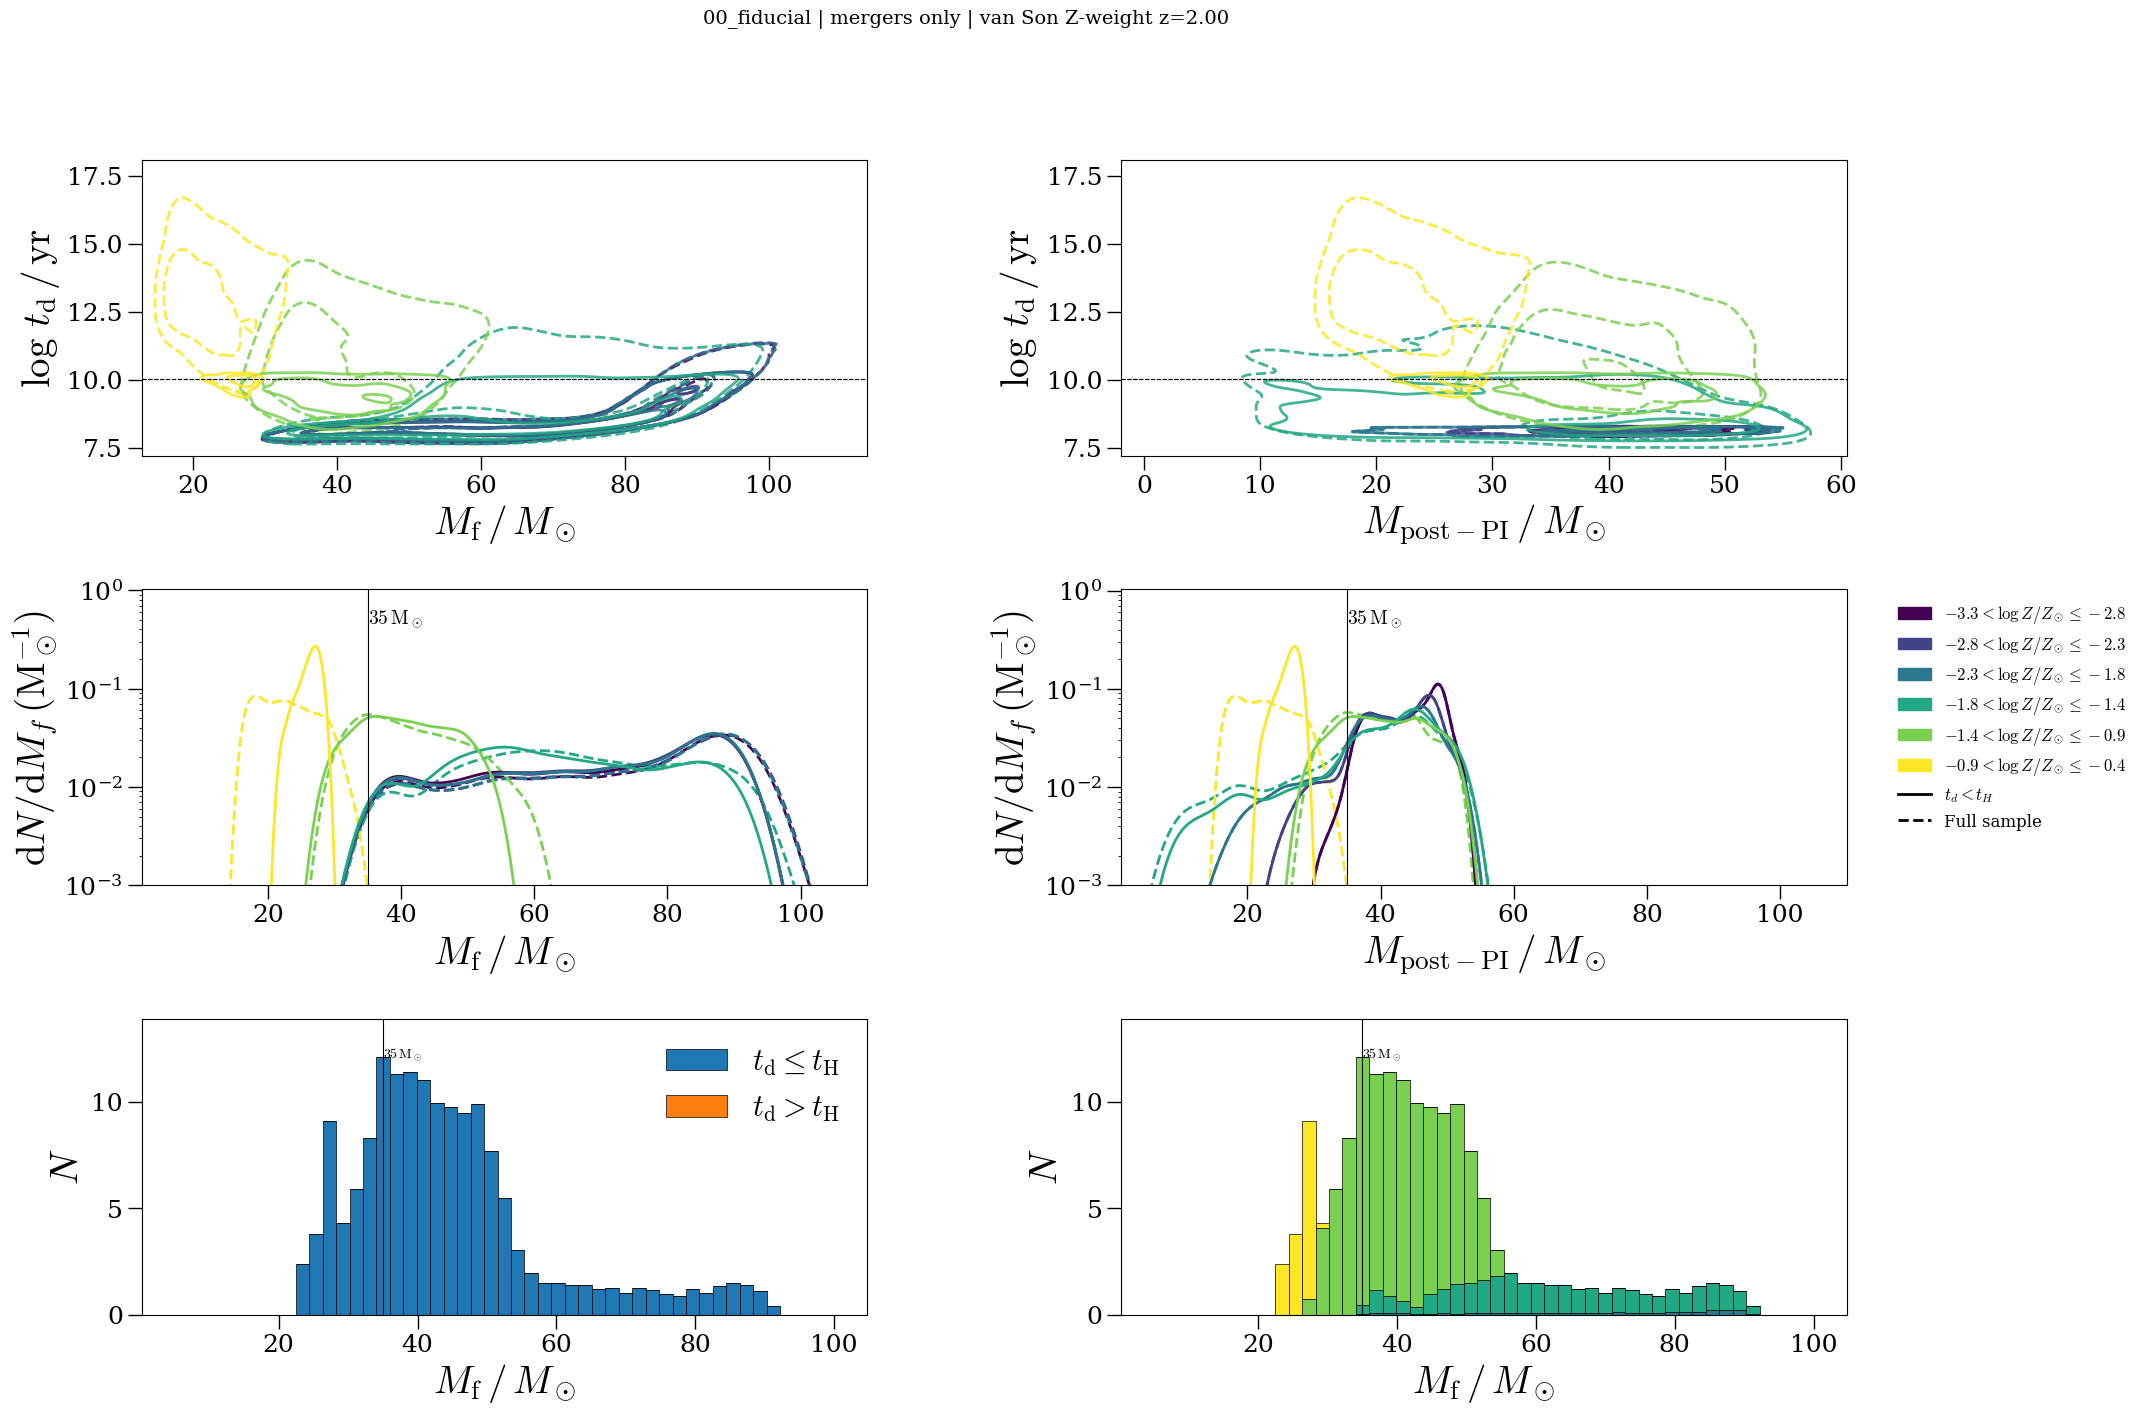

In [16]:
fiducial00_panel_fig = plot_results_panel_df(sample00_df, msample00_df, x_col=['m_f'], title='00_fiducial', save_figure=False, z_weight_redshift=Z_WEIGHT_REDSHIFT, mergers_only=MERGERS_ONLY)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


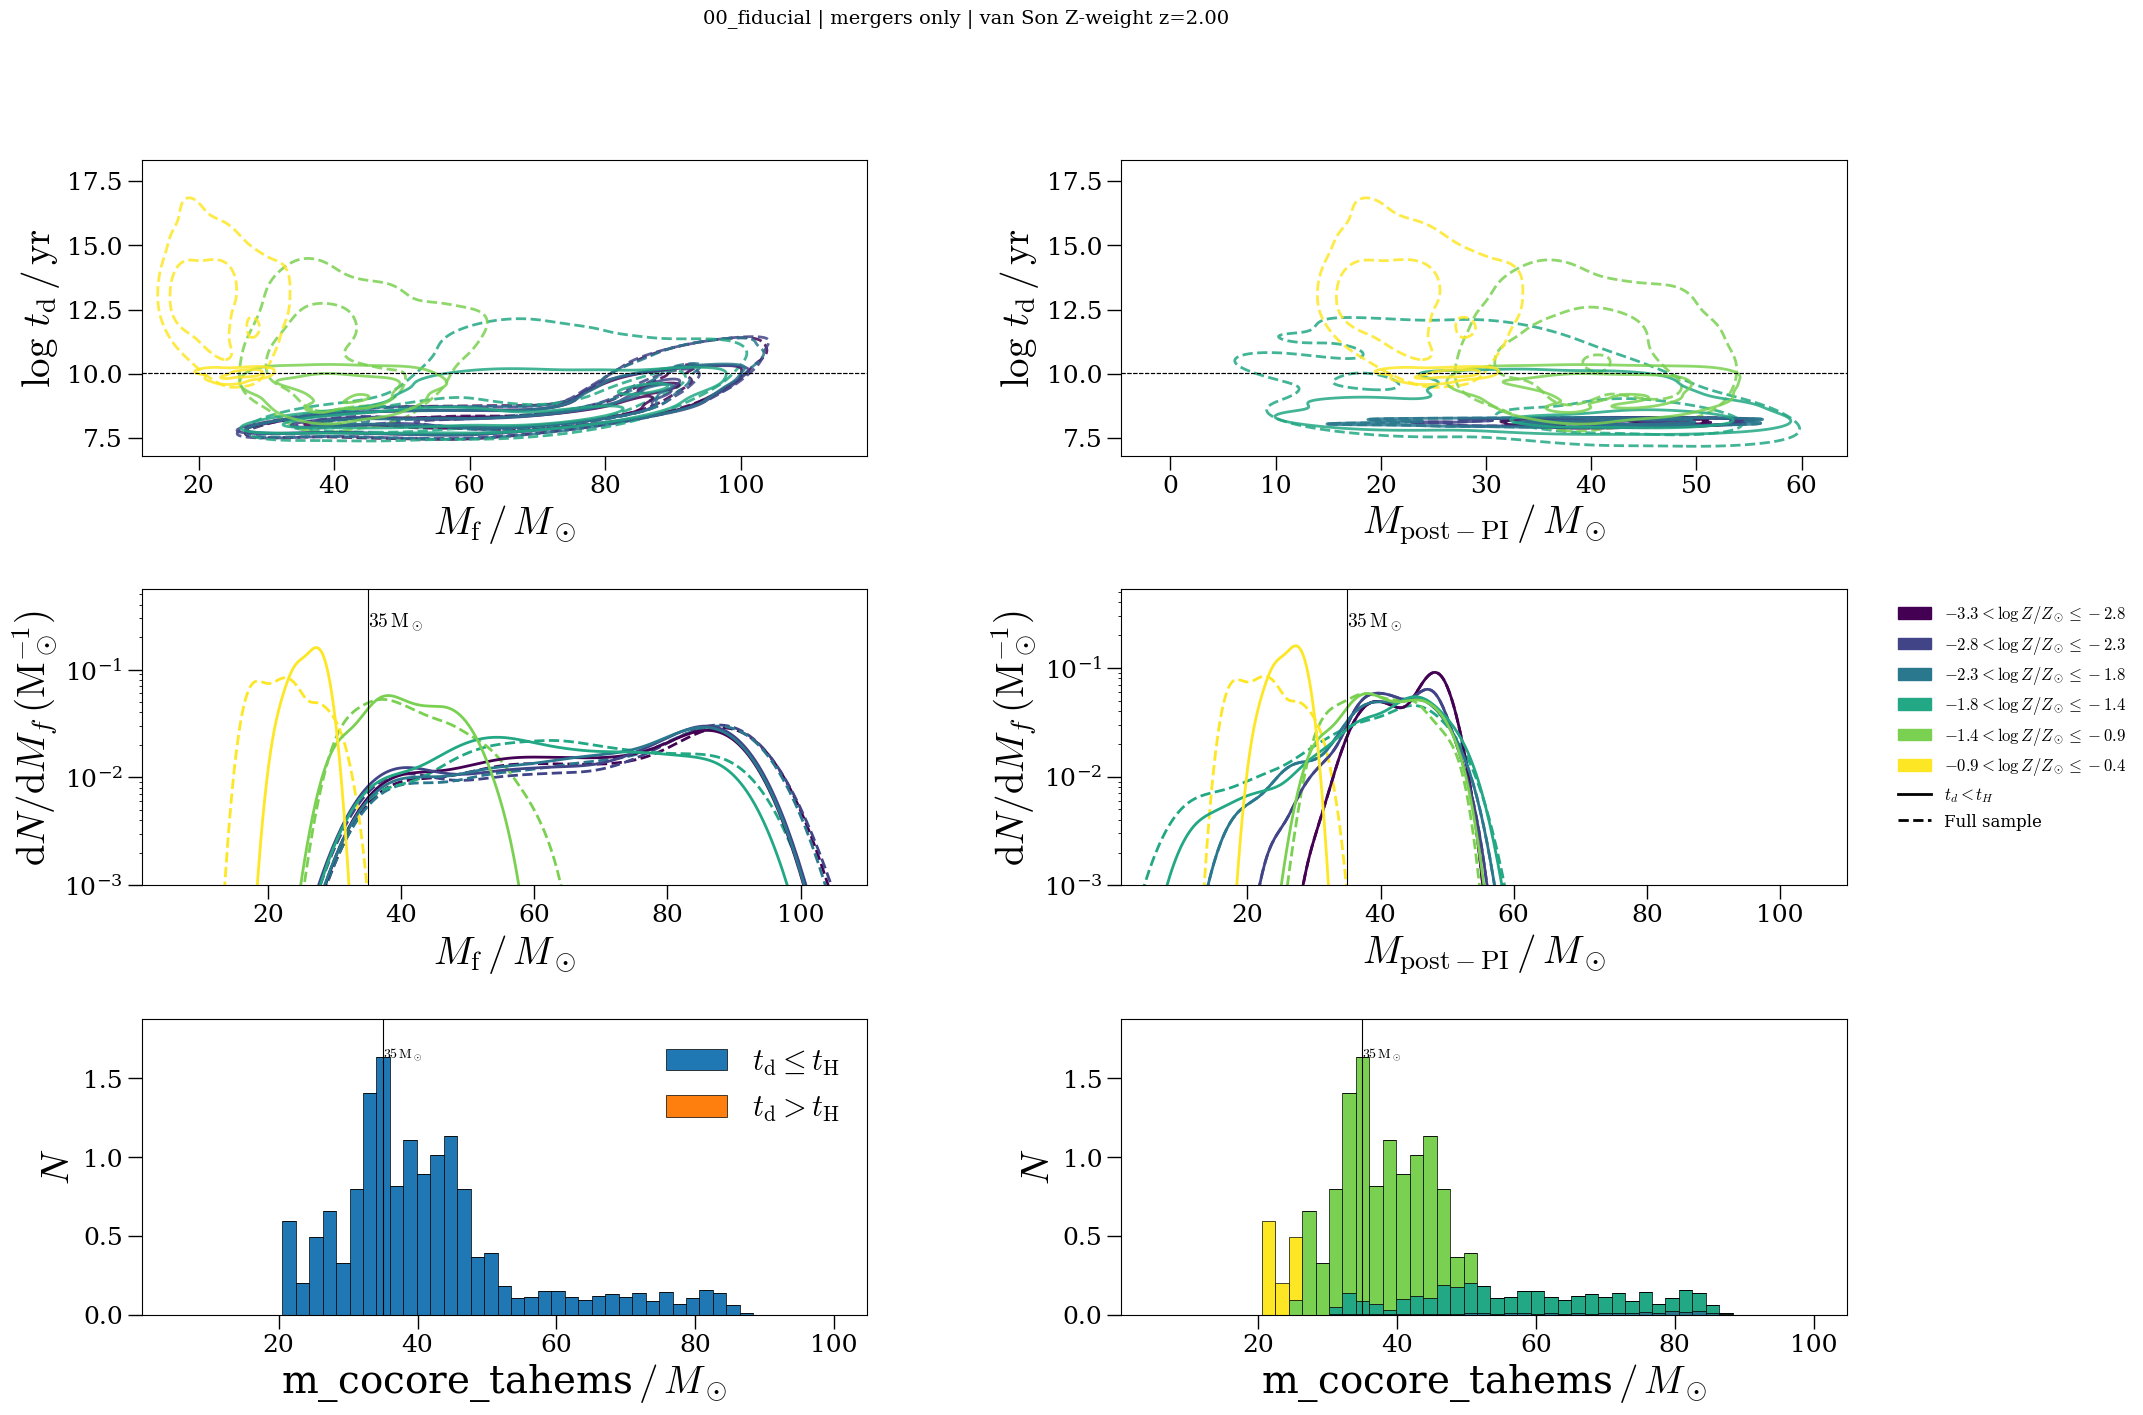

In [21]:
fiducial00_panel_fig = plot_results_panel_df(sample00_df, msample00_df, x_col=['m_cocore_tahems'], title='00_fiducial', save_figure=True, z_weight_redshift=Z_WEIGHT_REDSHIFT, mergers_only=MERGERS_ONLY)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


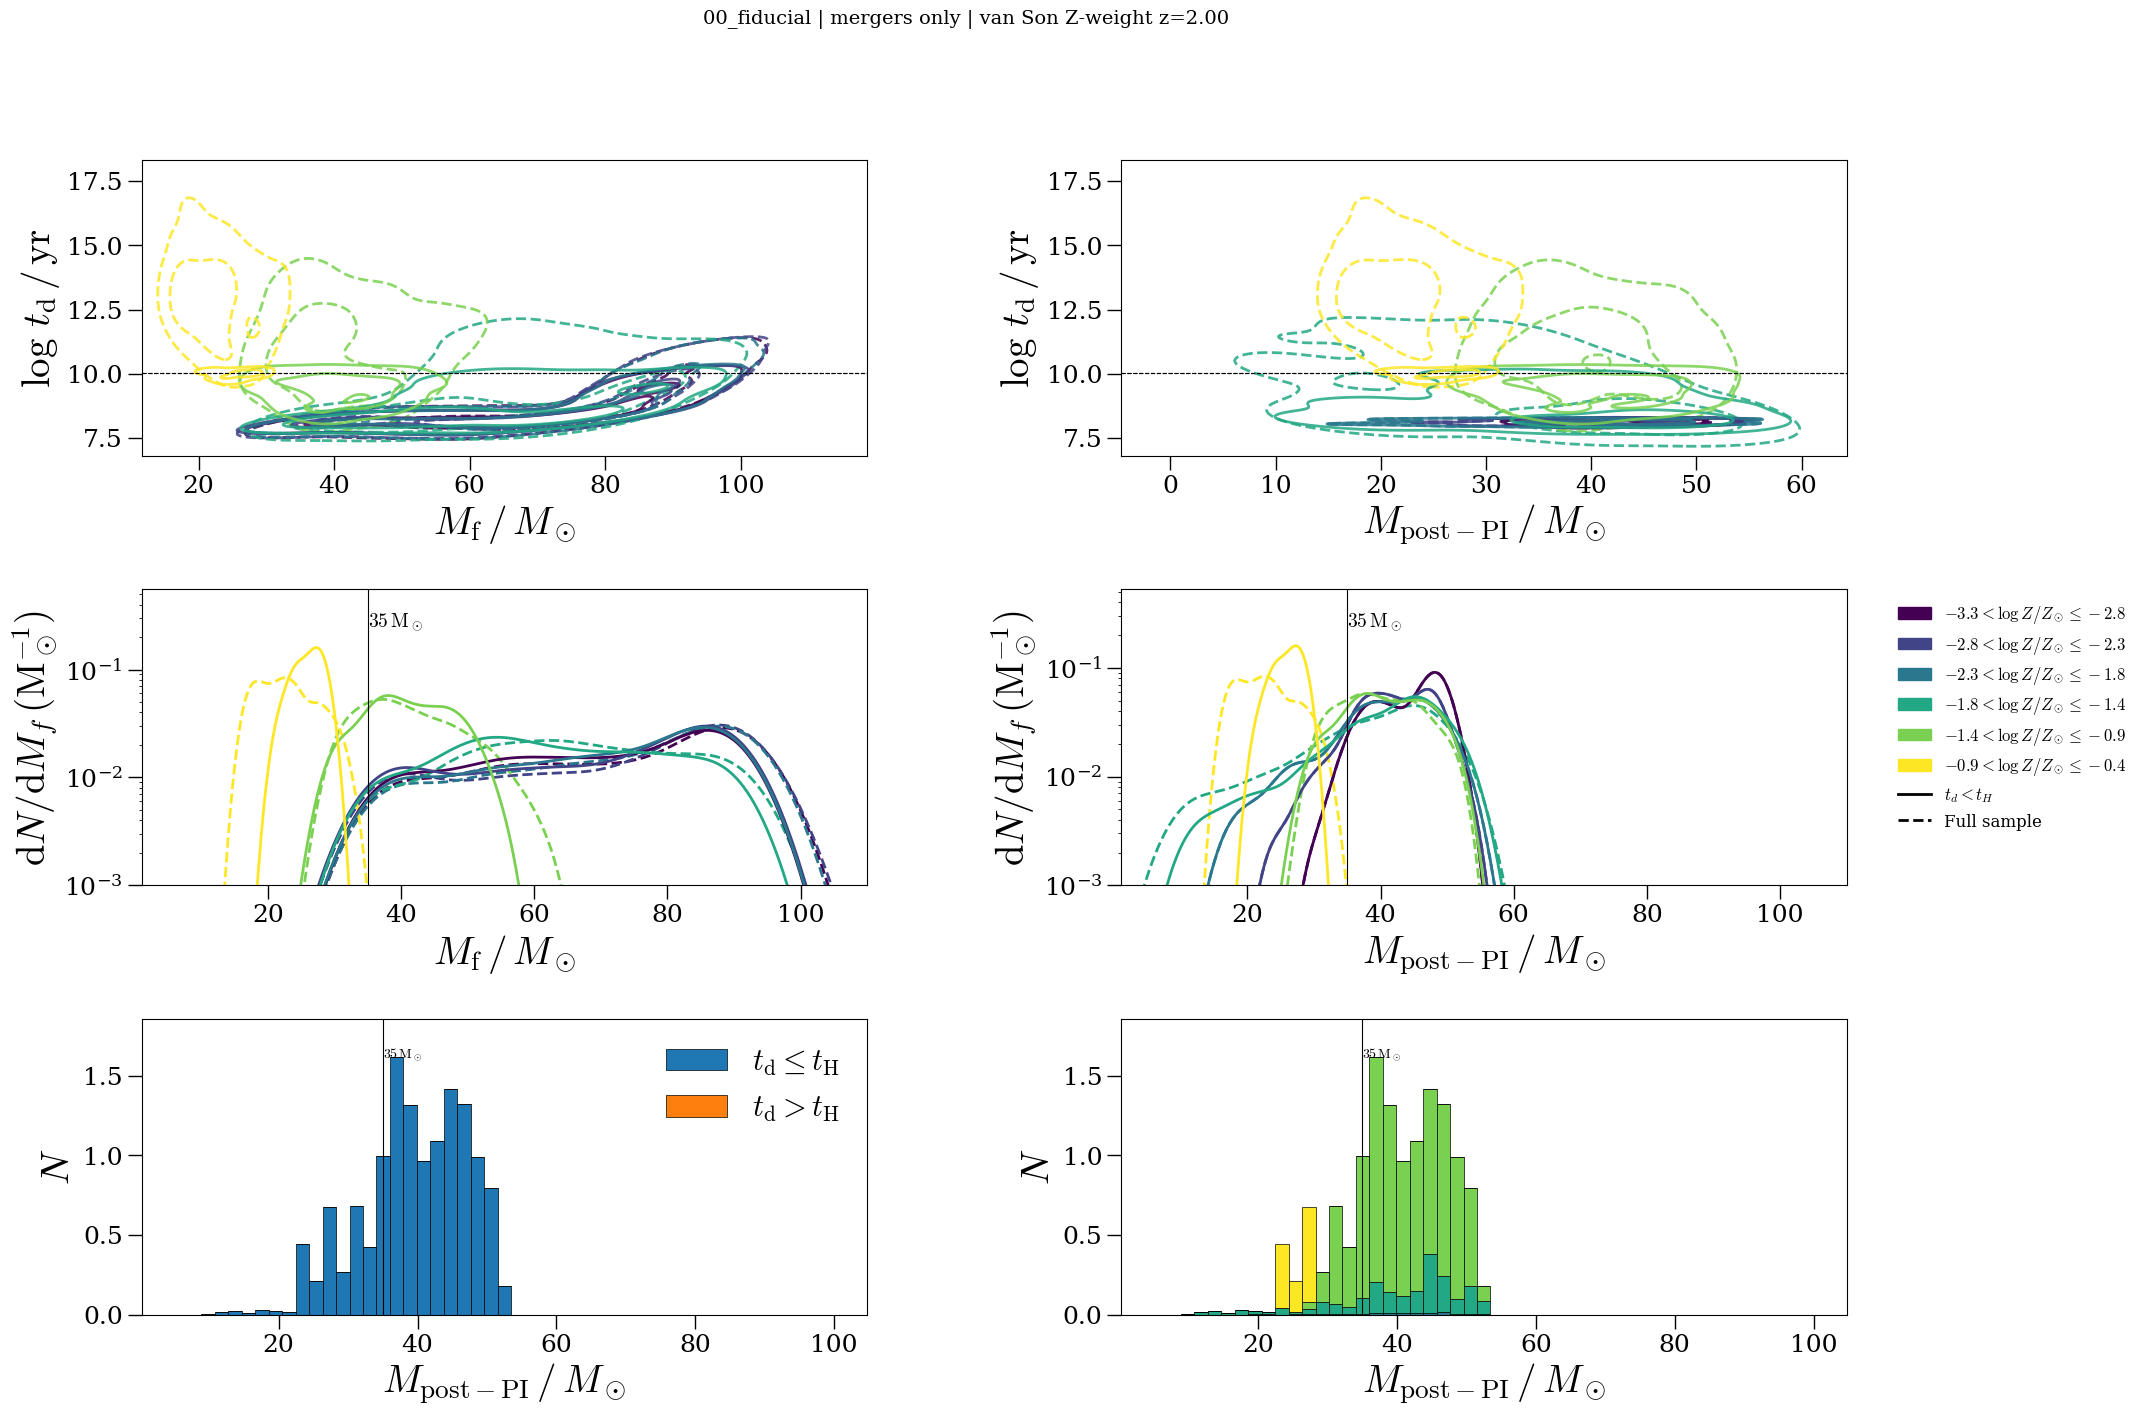

In [22]:
fiducial00_panel_fig = plot_results_panel_df(sample00_df, msample00_df, x_col=['m_post_pi'], title='00_fiducial', save_figure=True, z_weight_redshift=Z_WEIGHT_REDSHIFT, mergers_only=MERGERS_ONLY)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


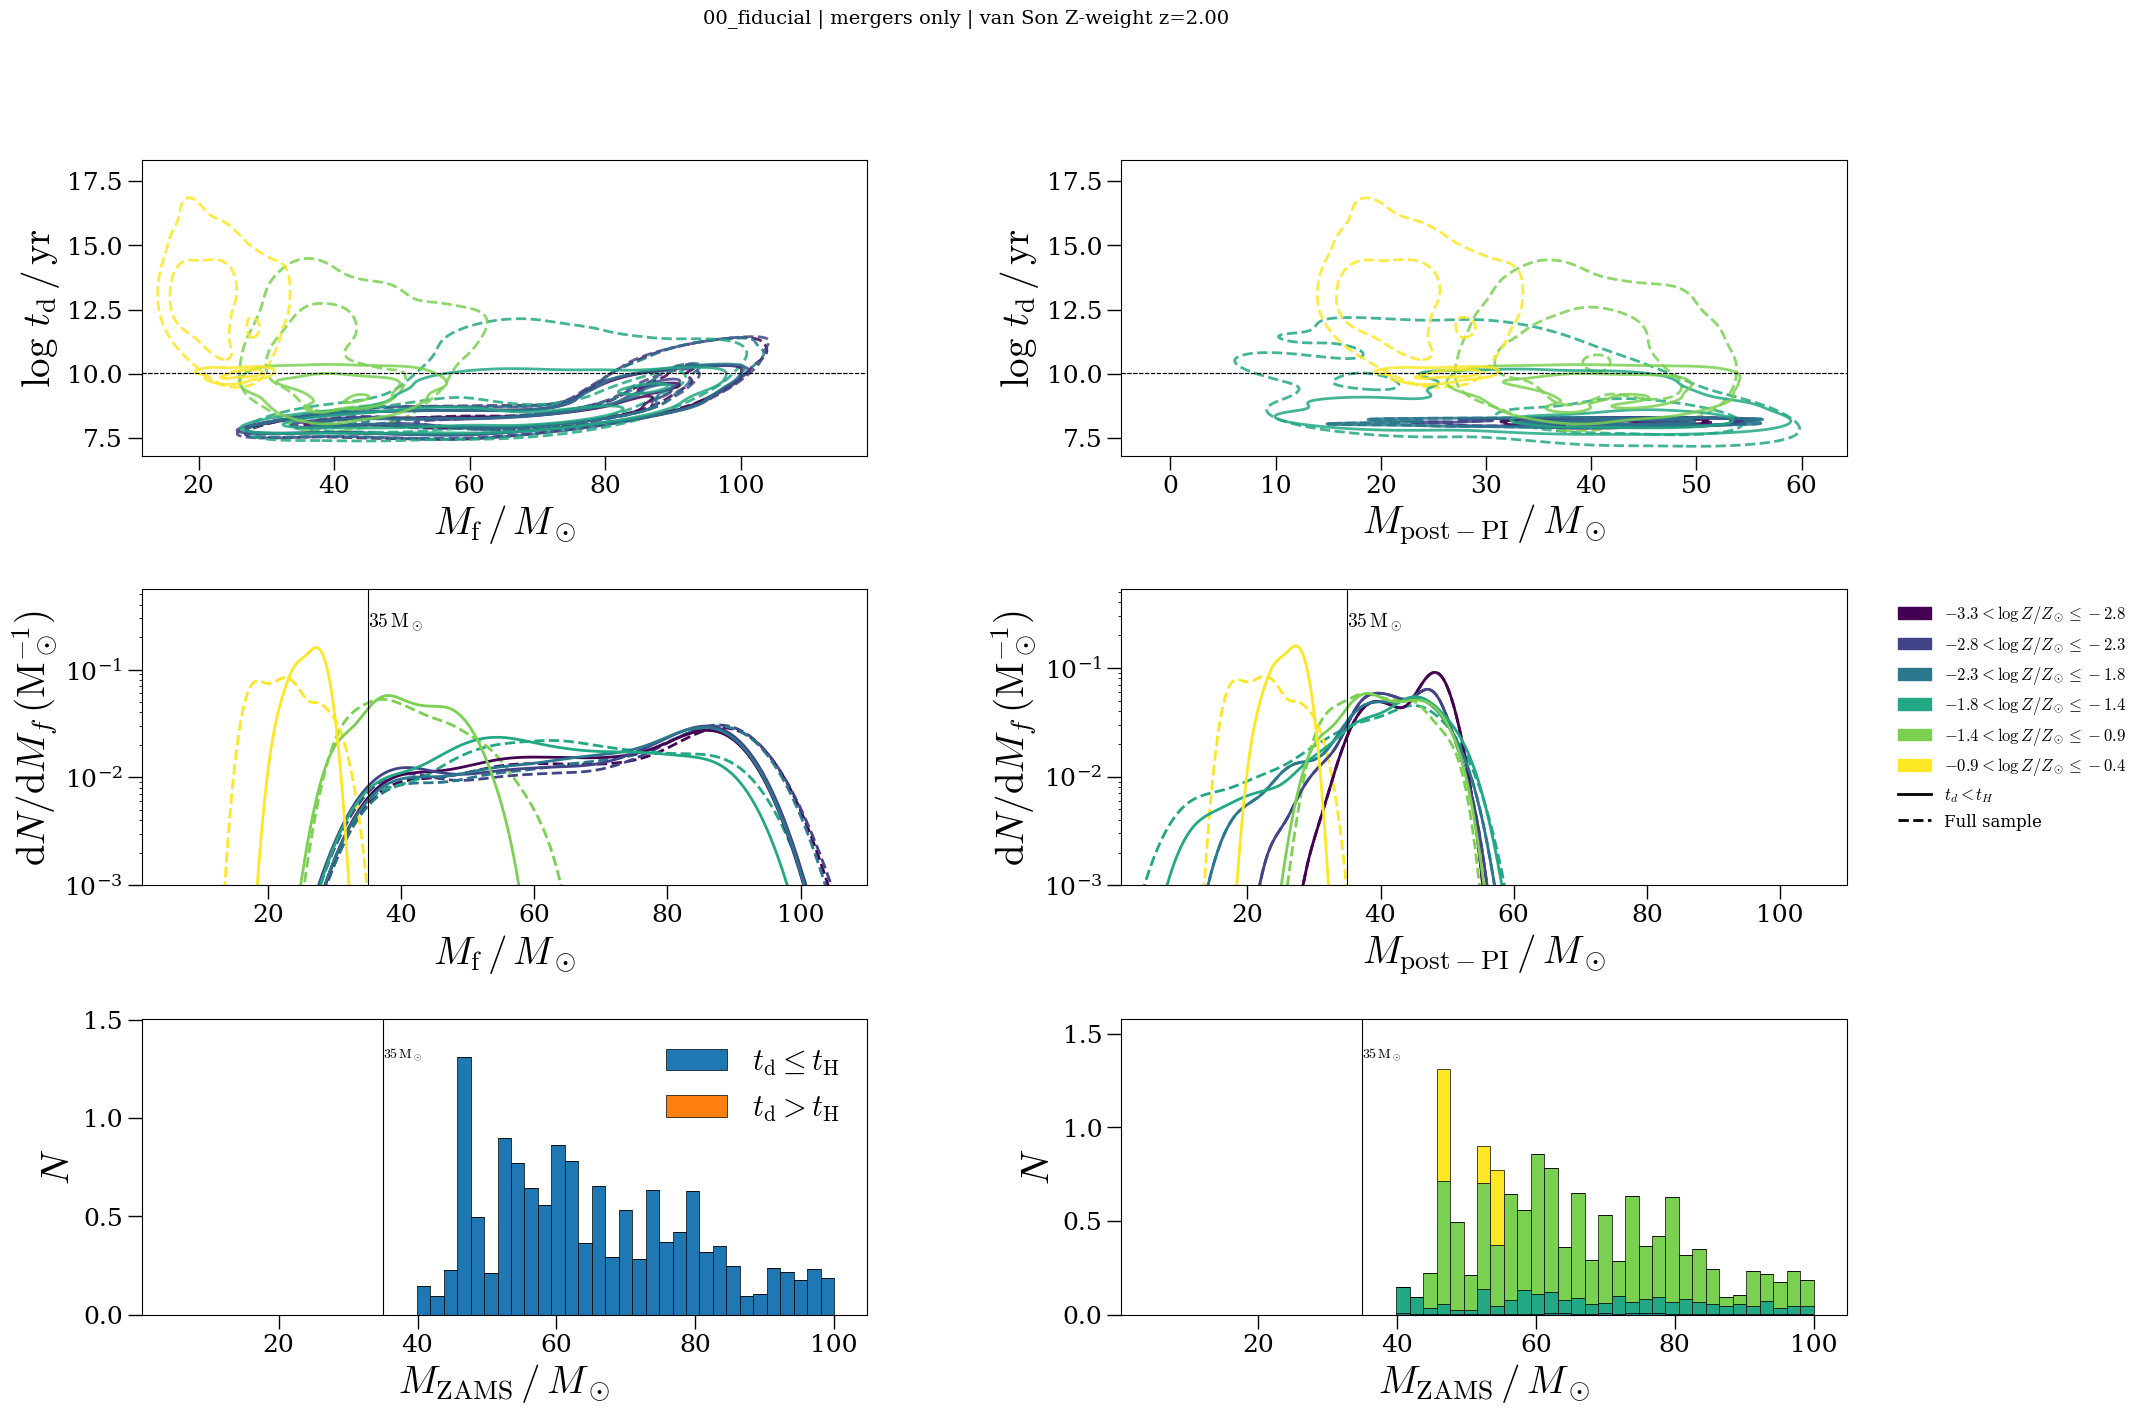

In [23]:
fiducial00_panel_fig = plot_results_panel_df(sample00_df, msample00_df, x_col=['m_zams'], title='00_fiducial', save_figure=True, z_weight_redshift=Z_WEIGHT_REDSHIFT, mergers_only=MERGERS_ONLY)

## Small variant grids

In [18]:
weakmix01_core_props_df = get_complete_core_props_df(DATA_DIR/'01_weakmix_core_props_df_v7.h5')
weakmix01_map_core_props_df = get_complete_core_props_df(DATA_DIR/'01_weakmix_core_props_df_map_v7.h5')

In [19]:
sample01_df, msample01_df, vars_index_dict = get_sample_df(
    weakmix01_core_props_df,
    map_core_props_df=weakmix01_map_core_props_df,
    dense_core_props_df=None,
    title_base='01_weakmix',
    save_to_disk=True,
    force_regen_sample=True,
    n_processes=30,
    cpu_affinity_count=30,
    model='interpolator',
    res=int(1e8),
    ppisn_config=farag_high_res_config,
    extrapolate_z_islands=True,
    interpolate_diagonals=False,
)

No sample at ../data/output/ip_pop/ip_pop_minz5e-4_maxz1e0_loguniform_interpolator_res1e+08_zextTrue_interpolator_01_weakmix_df.h5, or force_regen_sample=True. Generating new sample...
Set CPU affinity to use 30 CPUs: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29}
Fitting 'm_f' with model='interpolator'...
Fitting 'p_orb_f' with model='interpolator'...


/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=m_f] 26 isolated CHE node(s): no CHE neighbour among the 8 in-plane cells at the same metallicity. Are these crashed neighbors? Interpolator will continue. Cells: (45, 0.7, 0.0400), (50, 0.7, 0.0200), (70, 1.3, 0.4000), (80, 1.1, 0.3000), (80, 1.3, 0.0800), (80, 1.5, 0.3000), (80, 1.5, 0.4000), (100, 1, 0.0800), ... (+18 more)
  self.lip = PMZLinearInterpolator(
/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=m_f] 44 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XOXXXXX), (50, 0.8, XXOOXXX), (60, 0.9, XXOOOXX), (70, 0.9, XXOOXXX), (70, 1, XXXXOXX), (80, 0.9, XOOXXXX), (80, 1.2, XOXXXXX), (80, 1.3, XXOXXXX), .

Fitting 'x_f' with model='interpolator'...
Fitting 'x_min_f' with model='interpolator'...


/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=x_f] 26 isolated CHE node(s): no CHE neighbour among the 8 in-plane cells at the same metallicity. Are these crashed neighbors? Interpolator will continue. Cells: (45, 0.7, 0.0400), (50, 0.7, 0.0200), (70, 1.3, 0.4000), (80, 1.1, 0.3000), (80, 1.3, 0.0800), (80, 1.5, 0.3000), (80, 1.5, 0.4000), (100, 1, 0.0800), ... (+18 more)
  self.lip = PMZLinearInterpolator(
/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=x_f] 44 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XOXXXXX), (50, 0.8, XXOOXXX), (60, 0.9, XXOOOXX), (70, 0.9, XXOOXXX), (70, 1, XXXXOXX), (80, 0.9, XOOXXXX), (80, 1.2, XOXXXXX), (80, 1.3, XXOXXXX), .

Fitting 'm_tams' with model='interpolator'...
Fitting 'x_tams' with model='interpolator'...


/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=m_tams] 26 isolated CHE node(s): no CHE neighbour among the 8 in-plane cells at the same metallicity. Are these crashed neighbors? Interpolator will continue. Cells: (45, 0.7, 0.0400), (50, 0.7, 0.0200), (70, 1.3, 0.4000), (80, 1.1, 0.3000), (80, 1.3, 0.0800), (80, 1.5, 0.3000), (80, 1.5, 0.4000), (100, 1, 0.0800), ... (+18 more)
  self.lip = PMZLinearInterpolator(
/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=m_tams] 44 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XOXXXXX), (50, 0.8, XXOOXXX), (60, 0.9, XXOOOXX), (70, 0.9, XXOOXXX), (70, 1, XXXXOXX), (80, 0.9, XOOXXXX), (80, 1.2, XOXXXXX), (80, 1.3, XXOXX

Fitting 'log_t_d' with model='interpolator'...
Fitting 'm_cocore_tahems' with model='interpolator'...


/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=log_t_d] 26 isolated CHE node(s): no CHE neighbour among the 8 in-plane cells at the same metallicity. Are these crashed neighbors? Interpolator will continue. Cells: (45, 0.7, 0.0400), (50, 0.7, 0.0200), (70, 1.3, 0.4000), (80, 1.1, 0.3000), (80, 1.3, 0.0800), (80, 1.5, 0.3000), (80, 1.5, 0.4000), (100, 1, 0.0800), ... (+18 more)
  self.lip = PMZLinearInterpolator(
/gpfs/bwfor/work/ws/hd_lt355-cher2/repos/35peak_che/development_notebooks/../src/popsynth.py:2668: UserWarning: [PMZLinearInterpolator var=log_t_d] 44 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XOXXXXX), (50, 0.8, XXOOXXX), (60, 0.9, XXOOOXX), (70, 0.9, XXOOXXX), (70, 1, XXXXOXX), (80, 0.9, XOOXXXX), (80, 1.2, XOXXXXX), (80, 1.3, XXO

Saved 1000000 stars to ../data/ip_pop_minz0.0005_maxz1.0_res1e+08_interpolator_01_weakmix.npy
Saved 0 mergers to ../data/ip_pop_minz0.0005_maxz1.0_res1e+08_interpolator_01_weakmix_mergers_only.npy
Restoring original CPU affinity: {0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 62, 63}
len missing: 999082
len stable: 345
len ppisn: 225
len pisn: 348
len pd: 0
len total: 918
Saved sample dataframe: ../data/output/ip_pop/ip_pop_minz5e-4_maxz1e0_loguniform_interpolator_res1e+08_zextTrue_interpolator_01_weakmix_df.h5
Saved sampling configuration: ../data/output/ip_pop/ip_pop_minz5e-4_maxz1e0_loguniform_interpolator_res1e+08_zextTrue_interpolator_01_weakmix_sampling_config.pkl


In [20]:
Z_WEIGHT_REDSHIFT = 2
MERGERS_ONLY = False


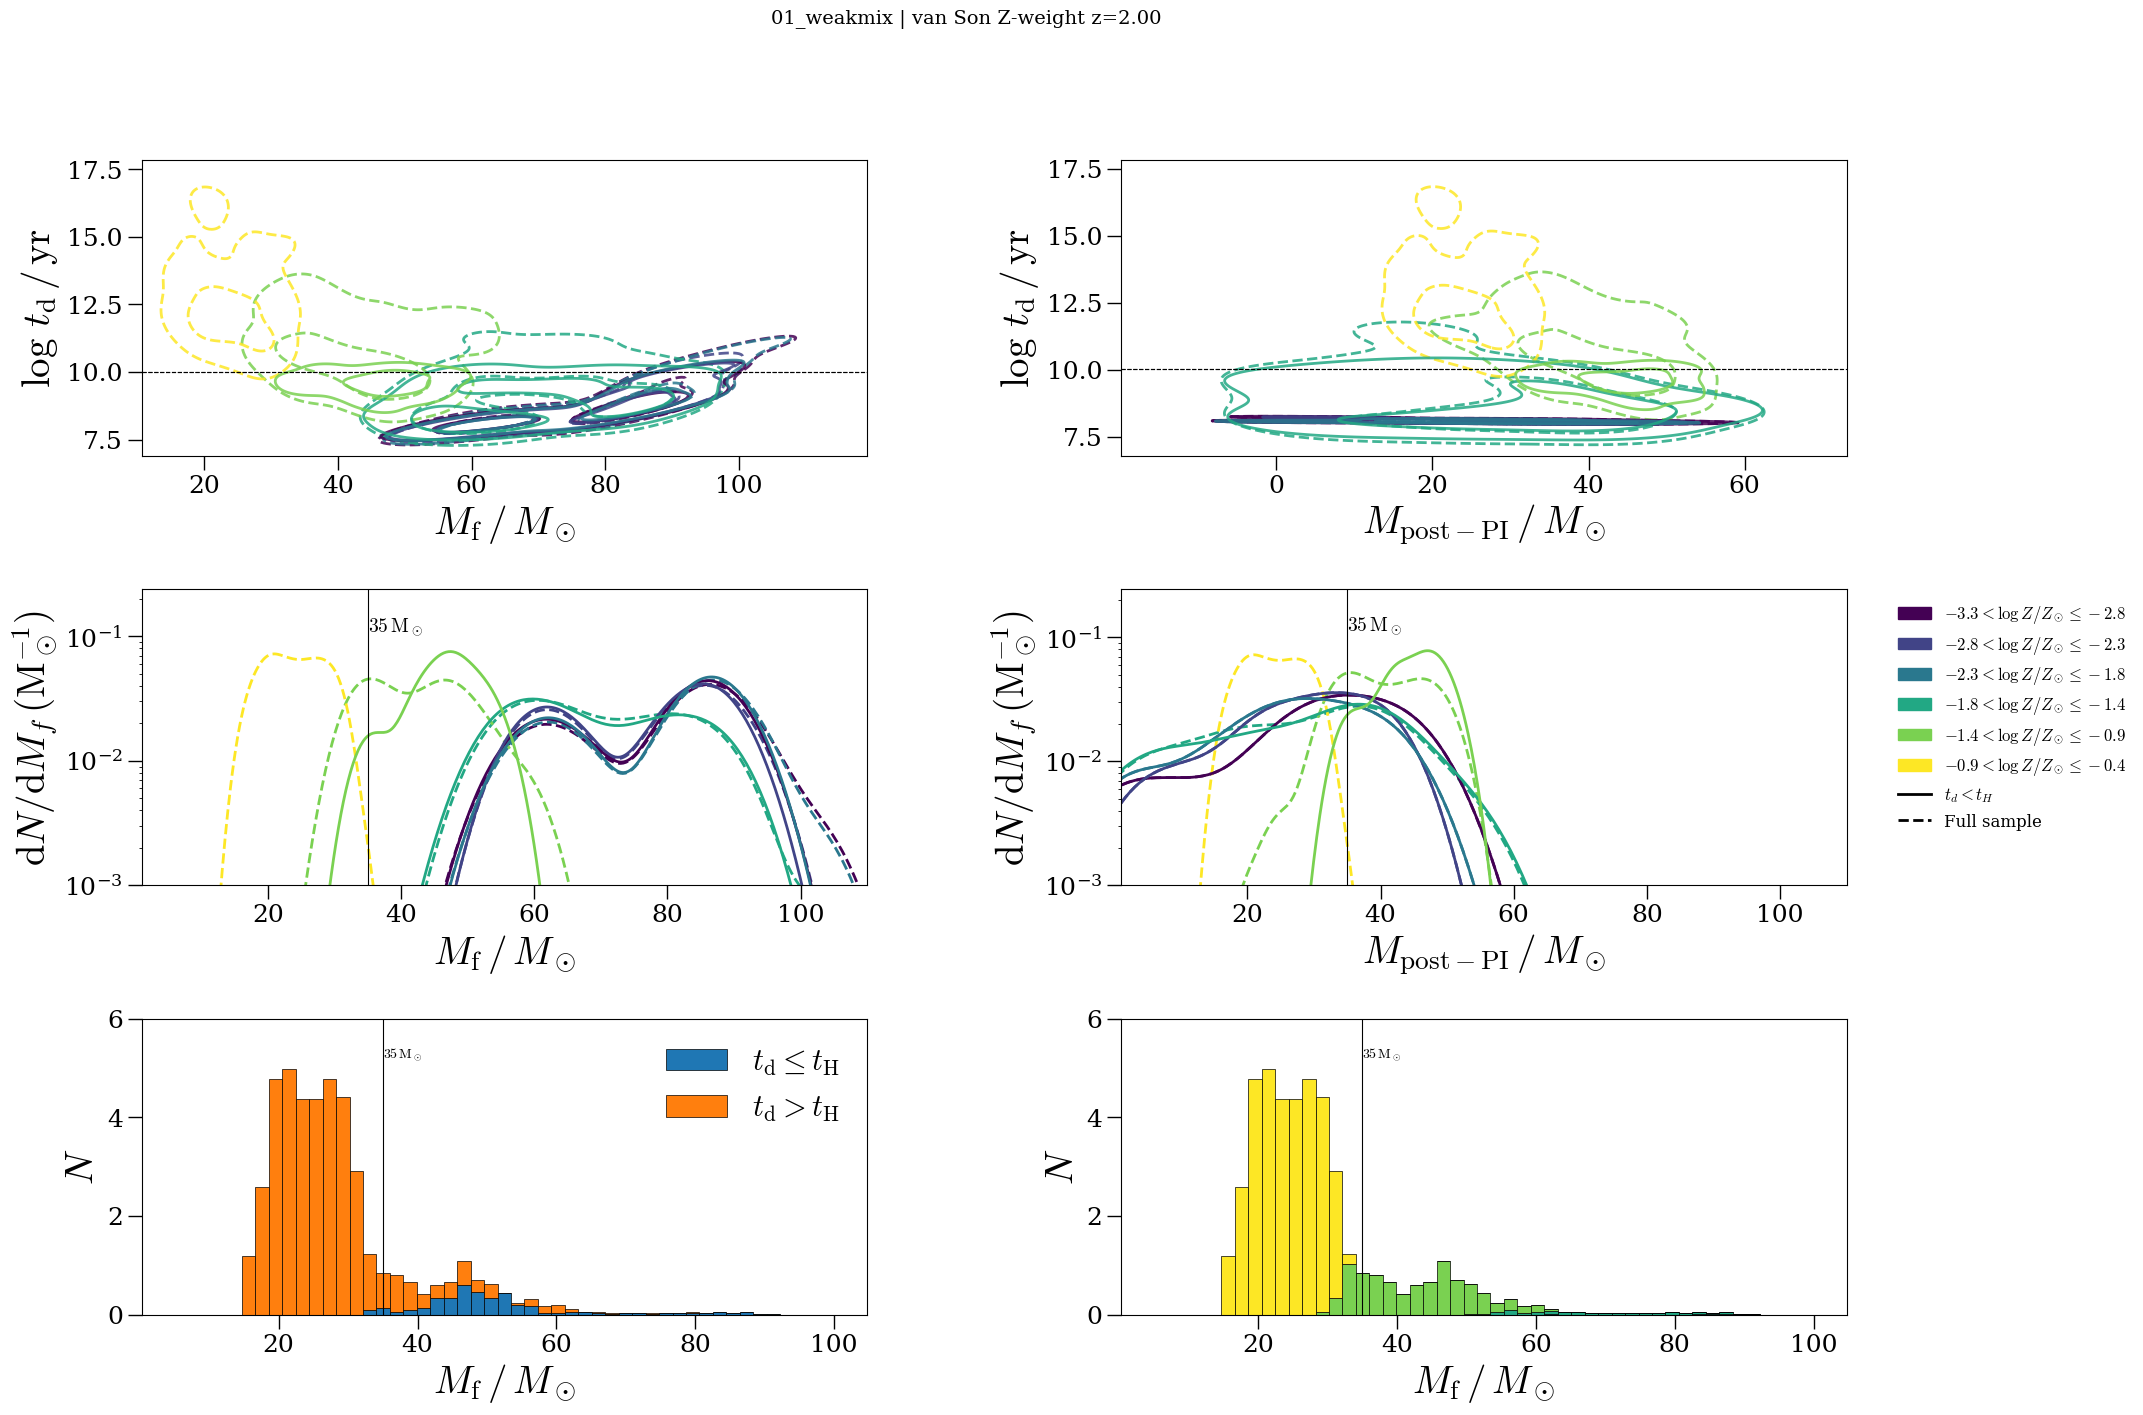

In [21]:
fiducial01_panel_fig = plot_results_panel_df(sample01_df, msample01_df, x_col=['m_f'], title='01_weakmix', save_figure=False, z_weight_redshift=Z_WEIGHT_REDSHIFT, mergers_only=MERGERS_ONLY)